Which sports does Team USA consistently rank in the top 8 but does not tend to medal in? 

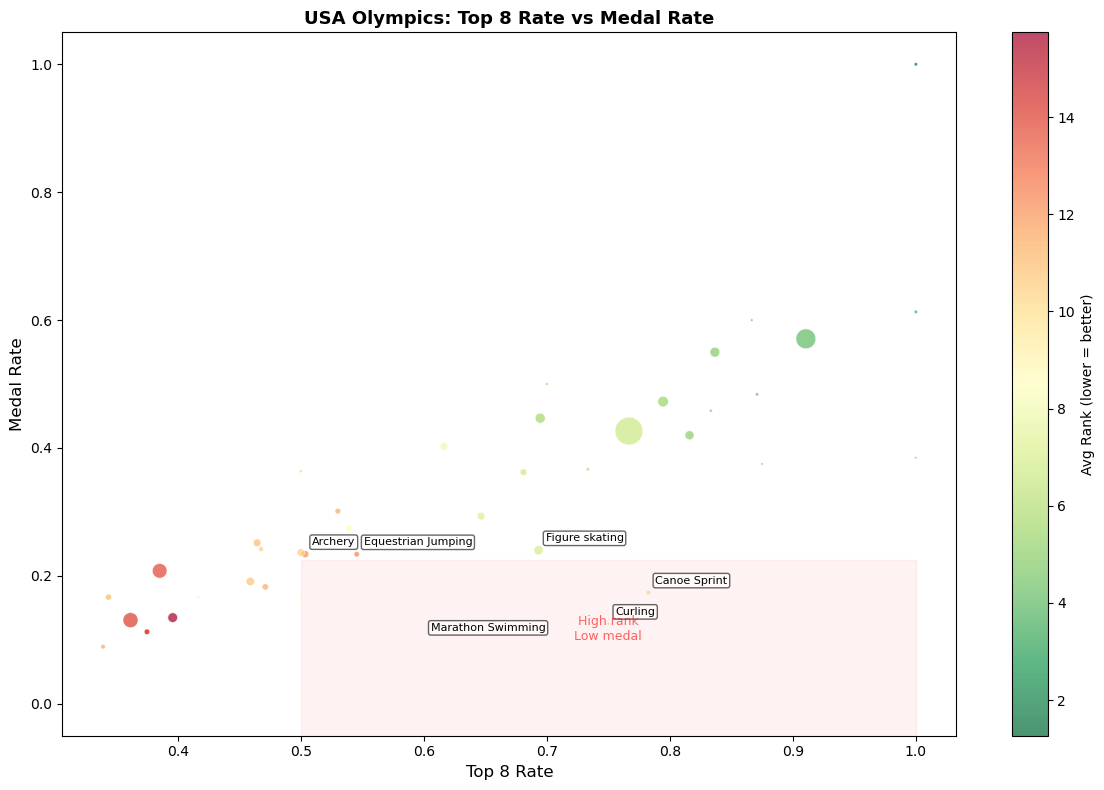

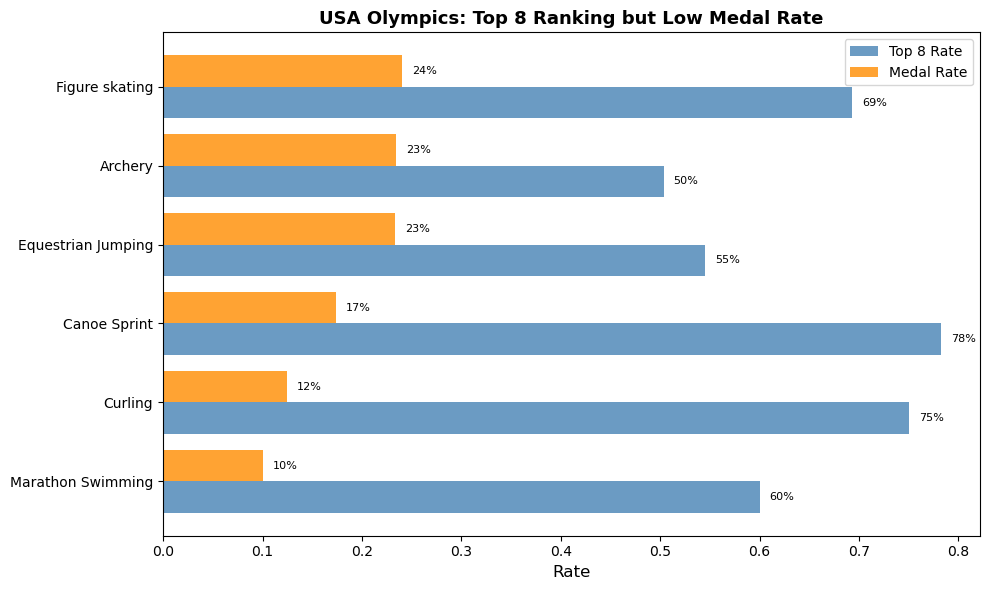

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Load Data ──────────────────────────────────────────────────────────────────
results_df = pd.read_csv('olympic_results.csv')

# ── Extract Year ───────────────────────────────────────────────────────────────
results_df['year'] = results_df['slug_game'].str[-4:].astype(int)

# ── Filter for USA ─────────────────────────────────────────────────────────────
us_results = results_df[results_df['country_3_letter_code'] == 'USA'].copy()

# ── Clean rank_position ────────────────────────────────────────────────────────
us_results['rank_position'] = pd.to_numeric(us_results['rank_position'], errors='coerce')
us_results = us_results.dropna(subset=['rank_position'])

# ── Flags ──────────────────────────────────────────────────────────────────────
us_results['is_medal'] = us_results['rank_position'] <= 3
us_results['is_top8']  = us_results['rank_position'] <= 8

# ── Aggregate by Discipline ────────────────────────────────────────────────────
summary = us_results.groupby('discipline_title').agg(
    total_appearances = ('rank_position', 'count'),
    total_medals      = ('is_medal', 'sum'),
    top8_finishes     = ('is_top8', 'sum'),
    avg_rank          = ('rank_position', 'mean')
).reset_index()

summary['medal_rate'] = summary['total_medals'] / summary['total_appearances']
summary['top8_rate']  = summary['top8_finishes'] / summary['total_appearances']

# ── Filter ─────────────────────────────────────────────────────────────────────
summary       = summary[summary['total_appearances'] >= 10]
undermedaling = (summary[summary['top8_rate'] > 0.3]
                         .sort_values(['medal_rate', 'top8_rate'],
                                       ascending=[True, False]))

# Sports to highlight — high top 8 rate but low medal rate
to_label = undermedaling[
    (undermedaling['top8_rate'] > 0.5) &
    (undermedaling['medal_rate'] < 0.25)
].sort_values('medal_rate')

# PLOT 1: Scatter — Top 8 Rate vs Medal Rate
fig1, ax1 = plt.subplots(figsize=(12, 8))

scatter = ax1.scatter(
    undermedaling['top8_rate'],
    undermedaling['medal_rate'],
    s=undermedaling['total_appearances'] / 5,
    c=undermedaling['avg_rank'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='white',
    linewidths=0.5
)

# Only label the to_label sports
for _, row in to_label.iterrows():
    ax1.annotate(row['discipline_title'],
                 (row['top8_rate'], row['medal_rate']),
                 fontsize=8, ha='left', va='bottom',
                 xytext=(5, 5), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

plt.colorbar(scatter, ax=ax1, label='Avg Rank (lower = better)')

# Shade the target quadrant
ax1.axvspan(0.5, 1.0, ymin=0, ymax=0.25 / 1.0,
            alpha=0.05, color='red')
ax1.text(0.75, 0.10, 'High rank\nLow medal', fontsize=9,
         color='red', alpha=0.6, ha='center')

ax1.set_xlabel('Top 8 Rate', fontsize=12)
ax1.set_ylabel('Medal Rate', fontsize=12)
ax1.set_title('USA Olympics: Top 8 Rate vs Medal Rate',
               fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# PLOT 2: Bar — Same sports labeled in scatter
fig2, ax2 = plt.subplots(figsize=(10, 6))

x = np.arange(len(to_label))
width = 0.4

ax2.barh(x - width/2, to_label['top8_rate'],  width,
         label='Top 8 Rate',  color='steelblue',  alpha=0.8)
ax2.barh(x + width/2, to_label['medal_rate'], width,
         label='Medal Rate',  color='darkorange', alpha=0.8)

ax2.set_yticks(x)
ax2.set_yticklabels(to_label['discipline_title'], fontsize=10)
ax2.set_xlabel('Rate', fontsize=12)
ax2.set_title('USA Olympics: Top 8 Ranking but Low Medal Rate',
               fontsize=13, fontweight='bold')
ax2.legend()

# Value labels on bars
for i, row in enumerate(to_label.itertuples()):
    ax2.text(row.top8_rate + 0.01,  i - width/2, f'{row.top8_rate:.0%}',  va='center', fontsize=8)
    ax2.text(row.medal_rate + 0.01, i + width/2, f'{row.medal_rate:.0%}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

The majority of the time, the USA ranks top 8 in figure skating, archery, equestrian jumping, canoe sprint, curling and marathon swimming but medals less than a quarter of the time.

Which countries medal for these sports often? 

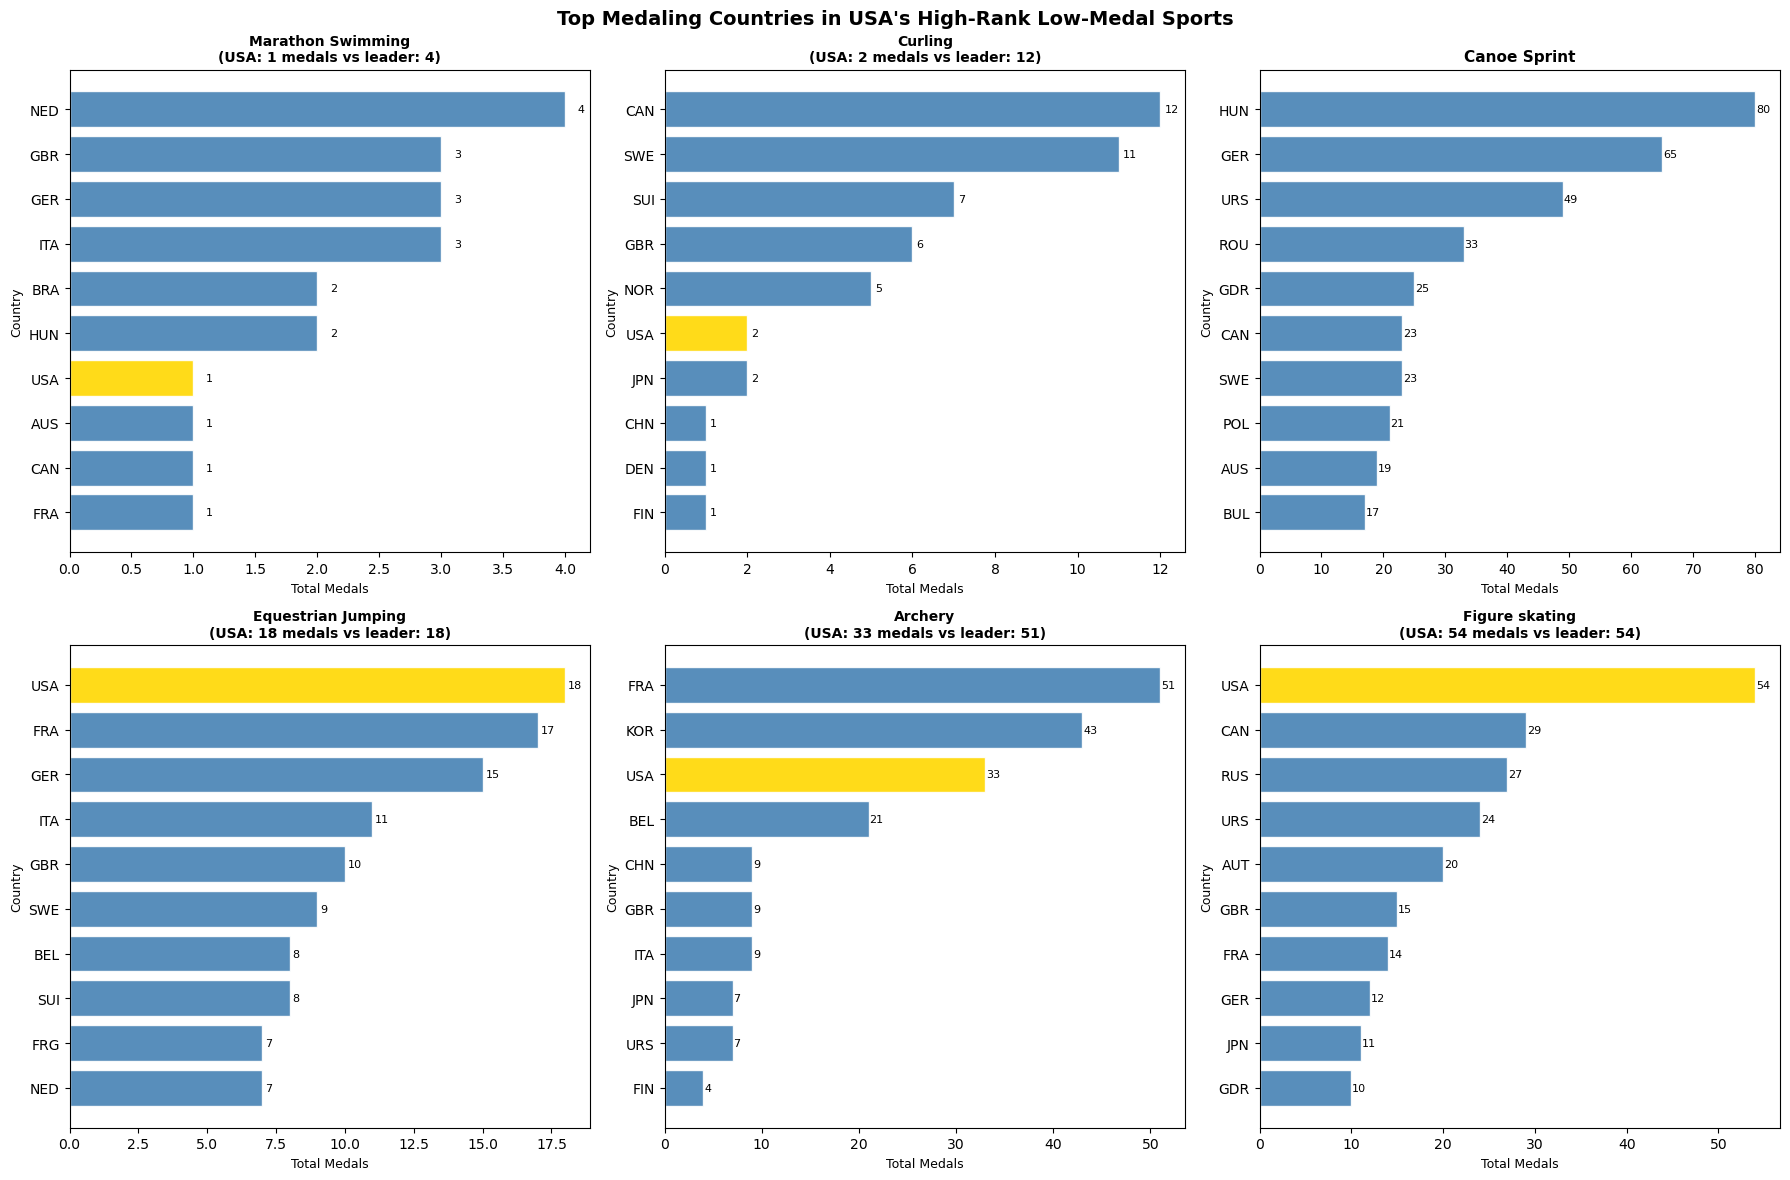

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Filter medals data for the labeled sports ──────────────────────────────────
target_sports = to_label['discipline_title'].tolist()

medals_df = results_df[
    (results_df['discipline_title'].isin(target_sports)) &
    (pd.to_numeric(results_df['rank_position'], errors='coerce') <= 3)
].copy()

medals_df = medals_df.dropna(subset=['rank_position'])
medals_df['rank_position'] = pd.to_numeric(medals_df['rank_position'], errors='coerce')
medals_df = medals_df[medals_df['rank_position'] <= 3]

# Count medals by sport and country
country_medals = (medals_df.groupby(['discipline_title', 'country_3_letter_code'])
                            .size()
                            .reset_index(name='medal_count'))

# ── Sort: by medal_count desc, USA first on ties ───────────────────────────────
country_medals['is_usa']    = (country_medals['country_3_letter_code'] == 'USA').astype(int)
country_medals              = country_medals.sort_values(
                                ['discipline_title', 'medal_count', 'is_usa'],
                                ascending=[True, False, False]  # USA floats up on ties
                              ).drop(columns='is_usa')

# ══════════════════════════════════════════════════════════════════════════════
# PLOT: Top medaling countries per sport
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, sport in enumerate(target_sports):
    ax = axes[i]

    sport_df = country_medals[country_medals['discipline_title'] == sport].head(10)
    colors   = ['gold' if c == 'USA' else 'steelblue' for c in sport_df['country_3_letter_code']]

    bars = ax.barh(sport_df['country_3_letter_code'][::-1],
                   sport_df['medal_count'][::-1],
                   color=colors[::-1], edgecolor='white', alpha=0.9)

    # Value labels
    for bar, count in zip(bars, sport_df['medal_count'][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=8)

    ax.set_title(sport, fontsize=11, fontweight='bold')
    ax.set_xlabel('Total Medals', fontsize=9)
    ax.set_ylabel('Country', fontsize=9)

    # Highlight USA note
    if 'USA' in sport_df['country_3_letter_code'].values:
        usa_count = sport_df[sport_df['country_3_letter_code'] == 'USA']['medal_count'].values[0]
        top_count = sport_df['medal_count'].iloc[0]
        ax.set_title(f'{sport}\n(USA: {usa_count} medals vs leader: {top_count})',
                     fontsize=10, fontweight='bold')

plt.suptitle("Top Medaling Countries in USA's High-Rank Low-Medal Sports",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

How does the ranking of the top countries change over time? 

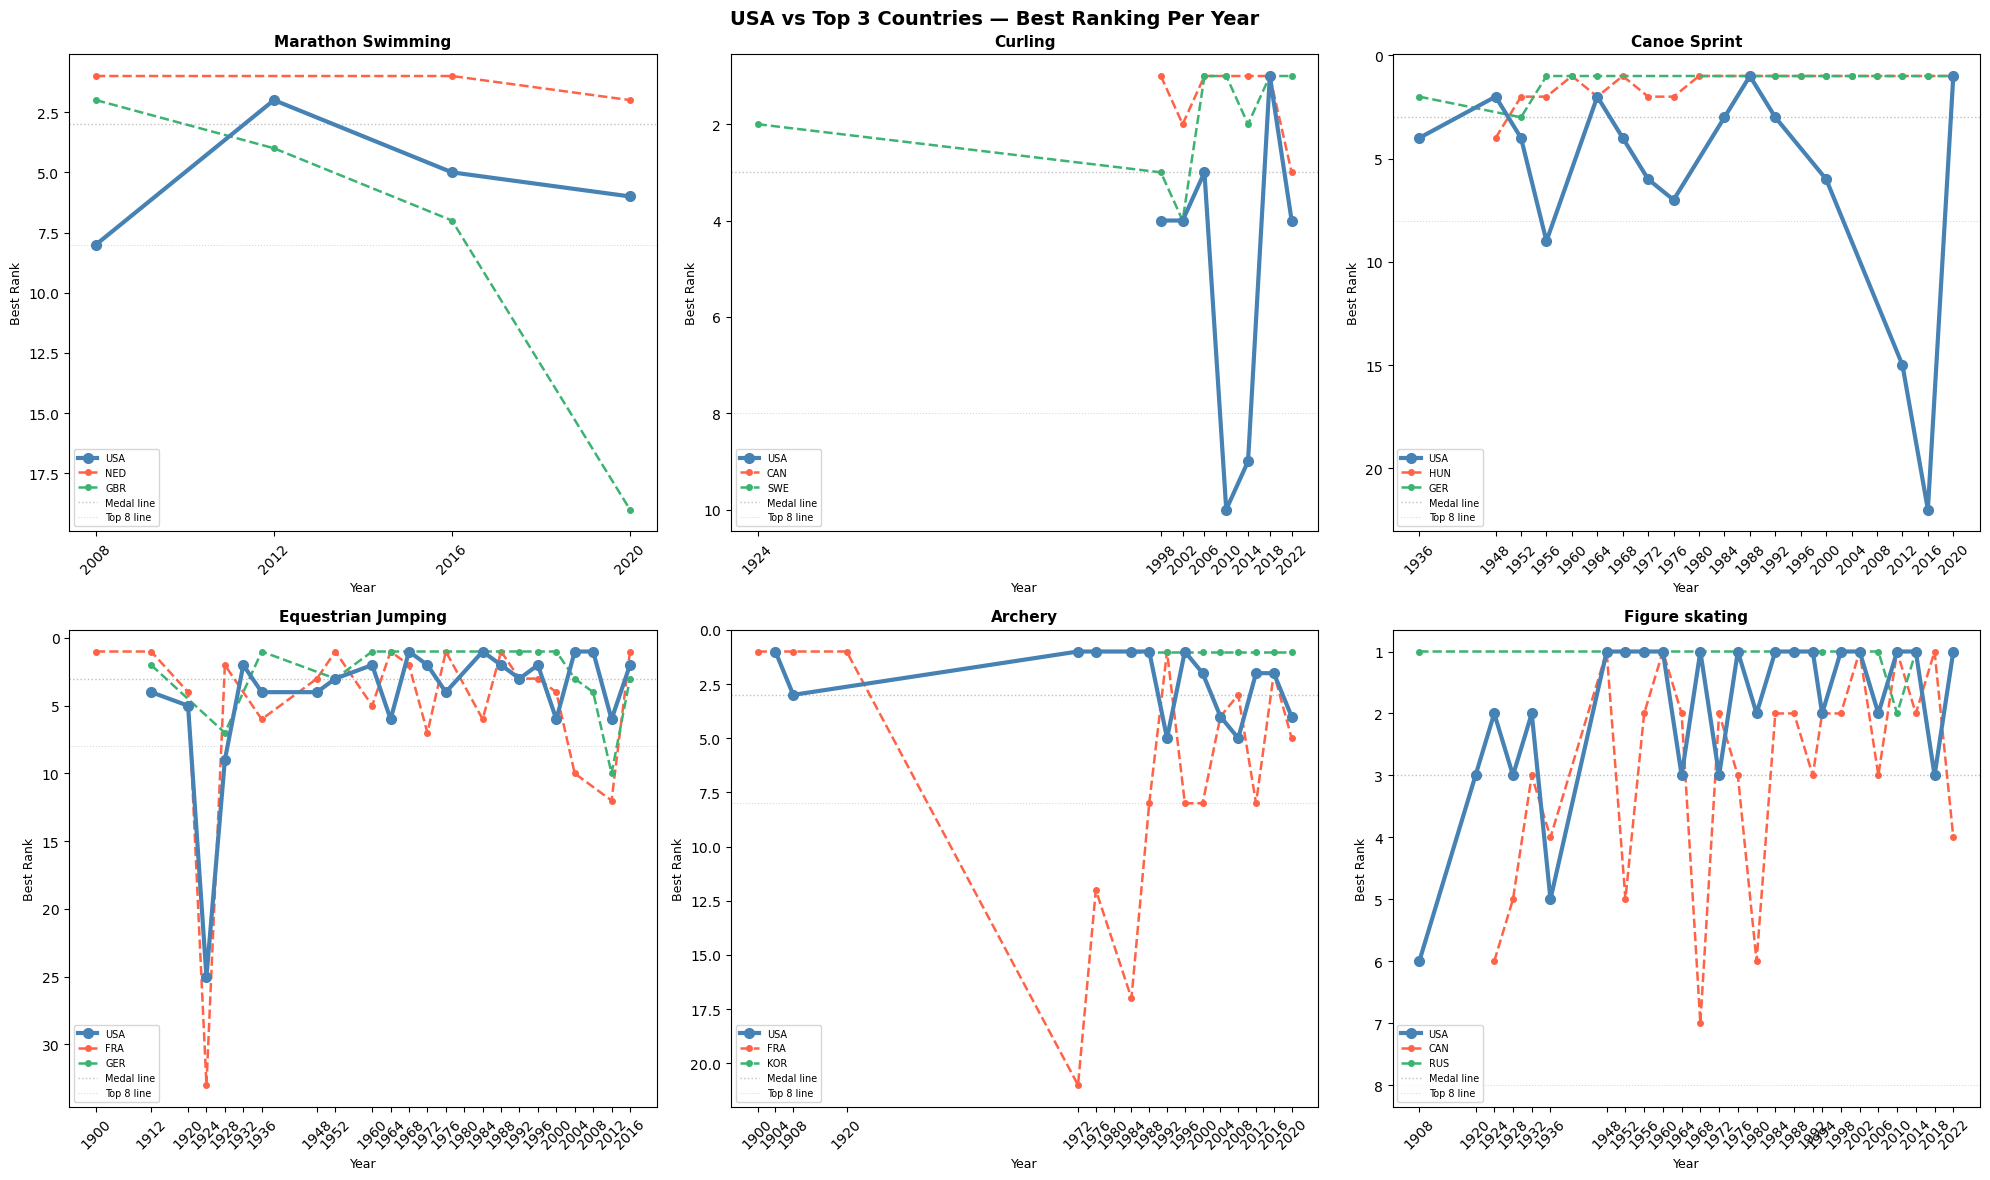

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Get best rank per sport per year for all countries ─────────────────────────
all_results = results_df[
    results_df['discipline_title'].isin(target_sports)
].copy()
all_results['rank_position'] = pd.to_numeric(all_results['rank_position'], errors='coerce')
all_results['year']          = all_results['slug_game'].str[-4:].astype(int)
all_results = all_results.dropna(subset=['rank_position'])

rank_by_year_all = (all_results.groupby(['discipline_title', 'country_3_letter_code', 'year'])
                               ['rank_position'].min().reset_index())

# ── Top 3 countries per sport by MEDAL COUNT (matches bar graph) ───────────────
medals_by_country = (all_results[all_results['rank_position'] <= 3]
                     .groupby(['discipline_title', 'country_3_letter_code'])
                     .size()
                     .reset_index(name='medal_count')
                     .sort_values(['discipline_title', 'medal_count'], ascending=[True, False]))


# PLOT
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

competitor_colors = ['tomato', 'mediumseagreen', 'mediumpurple']

for i, sport in enumerate(target_sports):
    ax = axes[i]

    # Top 3 by medal count for this sport (excluding USA)
    sport_top = (medals_by_country[
                    (medals_by_country['discipline_title'] == sport) &
                    (medals_by_country['country_3_letter_code'] != 'USA')
                 ]['country_3_letter_code'].head(2).tolist())

    # USA first, no duplicates
    countries = list(dict.fromkeys(['USA'] + sport_top))

    for j, country in enumerate(countries):
        sport_country_df = (rank_by_year_all[
            (rank_by_year_all['discipline_title'] == sport) &
            (rank_by_year_all['country_3_letter_code'] == country)
        ].sort_values('year'))

        if sport_country_df.empty:
            continue

        is_usa = country == 'USA'

        if is_usa:
            color      = 'steelblue'
            linewidth  = 3
            linestyle  = '-'
            markersize = 7
            zorder     = 5
        else:
            color      = competitor_colors[(j - 1) % len(competitor_colors)]
            linewidth  = 1.8
            linestyle  = '--'
            markersize = 4
            zorder     = 2

        ax.plot(sport_country_df['year'], sport_country_df['rank_position'],
                marker='o', linewidth=linewidth, color=color,
                markersize=markersize, zorder=zorder,
                linestyle=linestyle, label=country)

    ax.invert_yaxis()
    ax.axhline(y=3, color='gray', linestyle=':', linewidth=1,   alpha=0.5, label='Medal line')
    ax.axhline(y=8, color='gray', linestyle=':', linewidth=0.8, alpha=0.3, label='Top 8 line')
    ax.set_title(sport, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Best Rank', fontsize=9)
    ax.legend(fontsize=7, loc='lower left')

    all_years = rank_by_year_all[rank_by_year_all['discipline_title'] == sport]['year'].unique()
    ax.set_xticks(sorted(all_years))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("USA vs Top 3 Countries — Best Ranking Per Year",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()